In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
import Scripts.visualization as vis

FOS_Actual - FOS_target >= 0 
Stress (file:///C:/Users/natha/OneDrive/Documents/Daniel_YieldAndFailureCriteriaForCompositeMaterialsUnderStaticAndDynamicLoading_2015.pdf)
n = FOS n*[equation] <= 1
1st Natural Freq. (Hz) > Freq of Propeller Forcing Function (Hz) > 2nd Natural Freq. (Hz) 
RPM to Revolutions per second to Half revolutions per second 
Freq Propeller = RPM / 30 
Minimize Mass
Bounds on design variables
i.e. min wall thickness
(1/FOS%) * Power Used / Power Capacity >= 1  
FOS% = ~0.3
Minimize mass
$ min f(x)$ 

\begin{matrix}
1 & 0\\
0 & 1
\end{matrix}

(Use latex equations)

Failure Criterion: 0.1190415697623415
Failure Criterion + FOS: 0.3571247092870245
[  21.0566034    67.91184403   94.09845121  157.03366691  158.01450214
  201.51982889  283.30783311  287.99520689  297.76143135  421.29944659
  461.22550834  571.60849485 1239.37600448 1384.16810576 1986.0311394
 2570.56776492 2571.75634492 3887.3557847 ]


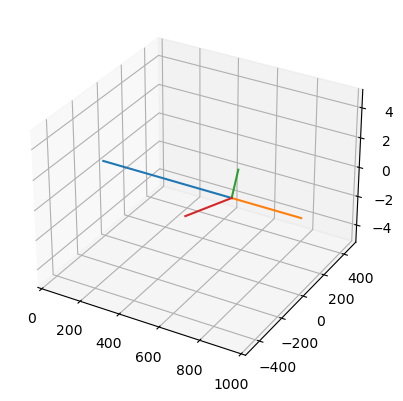

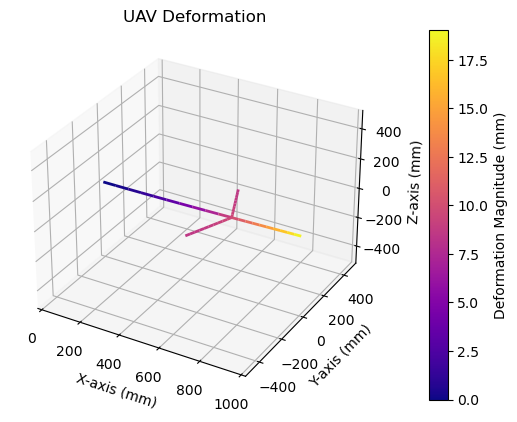

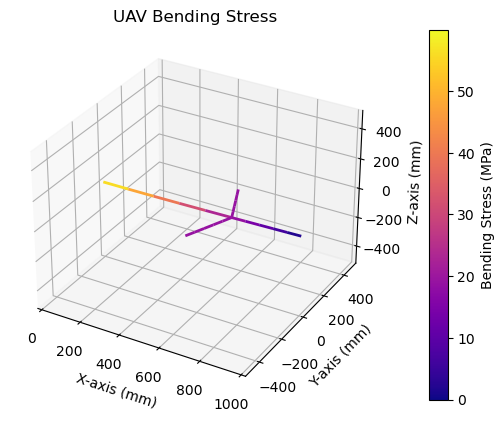

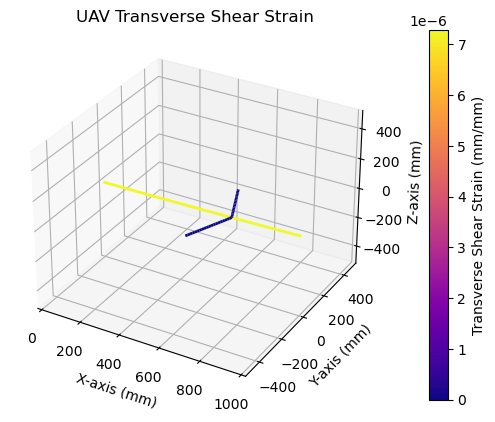

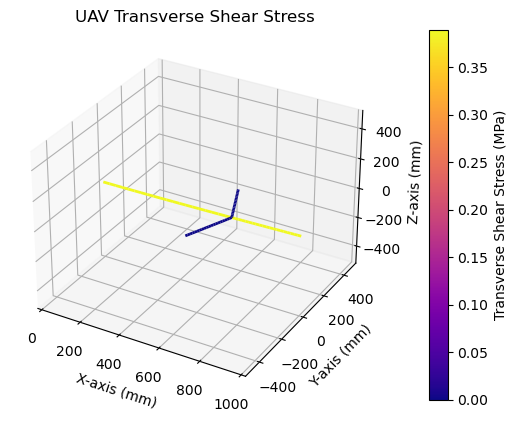

In [19]:
# SCIPY 
# FOS_Actual - FOS_target >= 0 
# # Stress (file:///C:/Users/natha/OneDrive/Documents
## /Daniel_YieldAndFailureCriteriaForCompositeMaterialsUnderStaticAndDynamicLoading_2015.pdf)
# # n = FOS n*[equation] <= 1
# # 1st Natural Freq. (Hz) > Freq of Propeller Forcing Function (Hz) > 2nd Natural Freq. (Hz) 
# # RPM to Revolutions per second to Half revolutions per second 
# # Freq Propeller = RPM / 30 
# Minimize Mass
# Bounds on design variables
# # i.e. min wall thickness
# # (1/FOS%) * Power Used / Power Capacity >= 1  
# # FOS% = ~0.3
# # Minimize mass 


# Figure out Bounds on design variables

# Consider design parameters (constants) 
# Make the most sensitive parameters variables. 

drag_coeff = 0.256

# Battery geometry
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

# Beam properties
arm_beam_properties = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam_properties = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")

# Drone geometry
drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

# Mass analysis
drone_mass = DroneMass(drone_geometry)

total_mass = drone_mass.total_mass + (45 * 10 ** -3)
surface_area = drone_geometry.projected_surface_area

# Mission profile generation
mission_profile = MissionProfile("m1", 1, 0, 0)
mission_profile.add_segment("takeoff",2,0,2,0,1)
mission_profile.add_segment("climb",15,550000,100000,300,0)
mission_profile.add_segment("cruise",50,2000000,110000,300,0)
mission_profile.add_segment("descent",10,2200000,50000,0,0)
mission_profile.add_segment("loiter",5,2200000,50000,0,0)
mission_profile.add_segment("land",10,2400000,0,0,0)

# Drone force analysis
d1_forces = DroneForces(total_mass, surface_area, drag_coeff, mission_profile)

# Drone Power Analysis
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)
drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)
drone_power.energy_consumption_calc(mission_profile.t_values, 2)
drone_power.throttle_ratio_calc(16) # Power for max throttle in kw w/ full battery

# FEA
d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
d1_fea.solve_fea()
d1_fea.beam_system.solve_natural_frequencies()

stress_FOS = 3

# this should be less than 1
# NU Daniel failure
print("Failure Criterion:", d1_fea.beam_system.max_failure_crit)
print("Failure Criterion + FOS:", d1_fea.beam_system.max_failure_crit * stress_FOS)


print(d1_fea.beam_system.natural_frequencies/(2*math.pi))

# NLP
# sqp <- check class notes






# plots
vis.drone_geometry(d1_fea)
vis.drone_geometry_deformation(d1_fea, 1, 10)
vis.drone_geometry_stress(d1_fea, 1, 5)
# vis.drone_geometry_strain(d1_fea, 1, 20)
vis.drone_geometry_strain_transverse_shear(d1_fea, 1, 20)
vis.drone_geometry_stress_transverse_shear(d1_fea, 1, 20)

In [16]:
 a = np.array([[-8,5,-1],[5,-6,-1],[-1,-1,0]])
b = np.array([[0],[0],[-4]])
print(np.linalg.solve(a,b))

[[ 1.83333333]
 [ 2.16666667]
 [-3.83333333]]


In [3]:
import numpy as np
H = np.array([[-8,5],[5,-6]])
eig = np.linalg.eigvals(H)
print(eig)

[-12.09901951  -1.90098049]


In [ ]:
import numpy
import scipy

# Steepest Descent Method 
# min f = x1^2 + 2*x2^2 + 2*x3 ^2 + 2x1 * x2 + 2 *x2 *x3
x0 = np.array([2, 4, 10])

convergenceEpsilon = 0.0001

k = 0
xK = x0

def ObjectiveFunction(xK):
    variables = 3
    x1, x2, x3 = 0
    vars_arr = [x1, x2, x3]
    f = x1 ** 2 + 2 * x2 ** 2 + 2 * x3 ** 2 + 2 * x1 * x2 + 2 * x2 * x3
    fVal = scipy.subs
    c = np.gradient(fVal)
    
fVal, cK, variables = ObjectiveFunction(xK)

print(np.linalg.norm(cK))
